# Libreries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Splits

In [2]:
X = pd.read_csv('/content/X_features.csv')
y = pd.read_csv('/content/y_target.csv')

print(X.shape, y.shape)

(115491, 18) (115491, 1)


# Función que valida NaN

In [3]:
def validar_X_y(X, y, target_name="is_profitable"):
    """
    Valida y sincroniza X e y antes de modelar.

    Parámetros:
    -----------
    X : pd.DataFrame
        Dataset de características.
    y : pd.Series o pd.DataFrame
        Target a predecir.
    target_name : str
        Nombre de la columna de target si es un DataFrame.

    Retorna:
    --------
    X_val : pd.DataFrame
        Dataset de características limpio.
    y_val : pd.Series
        Target limpio.
    """

    # Si y es un DataFrame, convertir a Series
    if isinstance(y, pd.DataFrame):
        if target_name in y.columns:
            y = y[target_name]
        else:
            raise ValueError(f"Target '{target_name}' no encontrado en DataFrame y.")

    # Concatenar X e y
    df_temp = pd.concat([X, y], axis=1)

    # Guardar shape original
    shape_original = df_temp.shape

    # Dropear filas con NaNs
    df_temp = df_temp.dropna()

    # Chequear cambios
    shape_final = df_temp.shape
    if shape_original != shape_final:
        print(f"Se eliminaron {shape_original[0] - shape_final[0]} filas por NaNs.")
    else:
        print("No se encontraron NaNs. X e y están limpios y sincronizados.")

    # Separar de nuevo
    X_val = df_temp.drop(y.name, axis=1)
    y_val = df_temp[y.name]

    # Validar shapes
    assert X_val.shape[0] == y_val.shape[0], "Error: X e y aún no tienen el mismo número de filas."

    return X_val, y_val

In [4]:
# Llamada a la función para validar y limpiar
X, y = validar_X_y(X, y)

Se eliminaron 1 filas por NaNs.


# Entrenamiento Random Forest

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Tamaño de entrenamiento:', X_train.shape)
print('Tamaño de test:', X_test.shape)

Tamaño de entrenamiento: (92392, 18)
Tamaño de test: (23098, 18)


In [7]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
y_pred_proba_rf = rf.predict_proba(X_test)[:,1]

In [10]:
nuevo_threshold = 0.4

y_pred_threshold_rf = (y_pred_proba_rf >= nuevo_threshold).astype(int)

In [11]:
# Calculamos métricas

print("Resultados Random Forest (Threshold = 0.4)")
print("Accuracy:", round(accuracy_score(y_test, y_pred_threshold_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_threshold_rf), 4))
print('Recall:', round(recall_score (y_test, y_pred_threshold_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_threshold_rf), 4))
print('ROC AUC Score:', round(roc_auc_score(y_test, y_pred_threshold_rf), 4))

print('Classification Report:')
print(classification_report(y_test, y_pred_threshold_rf))

Resultados Random Forest (Threshold = 0.4)
Accuracy: 0.9999
Precision: 0.999
Recall: 0.999
F1 Score: 0.999
ROC AUC Score: 0.9995
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     22123
         1.0       1.00      1.00      1.00       975

    accuracy                           1.00     23098
   macro avg       1.00      1.00      1.00     23098
weighted avg       1.00      1.00      1.00     23098



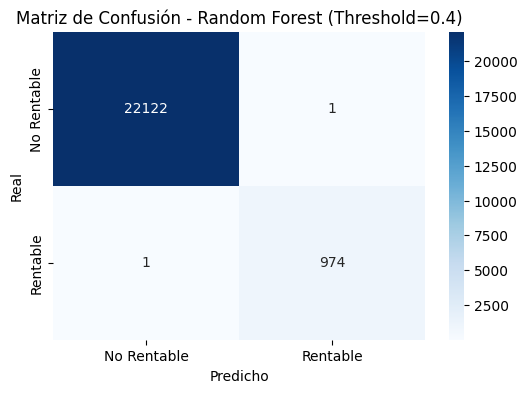

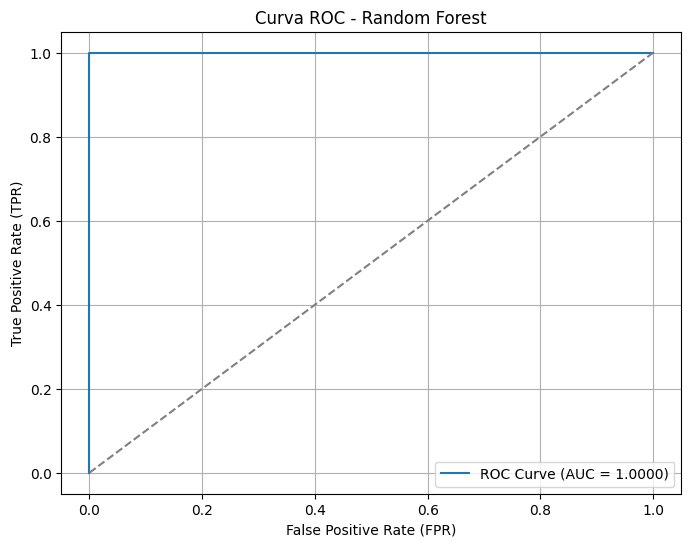

In [12]:
# Matriz de Confusión
conf_matrix_rf = confusion_matrix(y_test, y_pred_threshold_rf)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap="Blues", xticklabels=['No Rentable', 'Rentable'], yticklabels=['No Rentable', 'Rentable'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest (Threshold=0.4)')
plt.show()

#  Curva ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
auc_score_rf = roc_auc_score(y_test, y_pred_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'ROC Curve (AUC = {auc_score_rf:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Random Forest')
plt.legend()
plt.grid()
plt.show()

# Variables importantes

In [13]:
importances = rf.feature_importances_
features = X_train.columns

In [15]:
df_features = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

<ipython-input-17-aaa1c71562c9>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data= top10_features, palette="viridis")


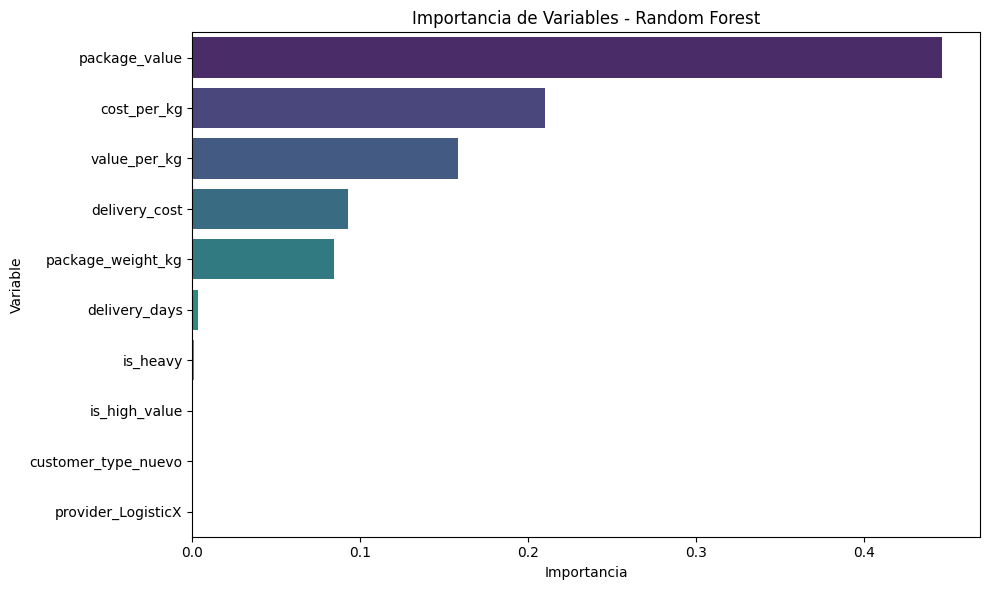

In [17]:
top10_features = df_features.head(10)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data= top10_features, palette="viridis")
plt.title('Importancia de Variables - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# Conclusiones - Random Forest Classifier

- El modelo de Random Forest logró una performance sobresaliente:
  - Accuracy, Precision, Recall y F1 Score superiores al 99.9%.
  - Área bajo la curva ROC (AUC) de 1.0000.
  - Sólo 2 errores de clasificación en 23,098 ejemplos de testeo.

- El análisis de importancia de variables reveló que:
  - `package_value` es la variable más influyente para determinar rentabilidad.
  - Ratios derivados como `cost_per_kg` y `value_per_kg` aportan información significativa.
  - Variables categóricas (tipo de cliente, proveedor, tipo de envío) tienen bajo impacto directo.

- Se confirma que Random Forest supera en performance a la Regresión Logística usada como baseline inicial.

-  Nota: Aunque `package_value` representa el valor declarado del paquete (y no directamente el precio de envío), su correlación con la rentabilidad parece reflejar patrones reales de negocio.

 Random Forest se establece como un modelo altamente efectivo para el problema de clasificación de rentabilidad logística.

---
